# Unseen Container — Hybrid Prophet + GRU Demo

Standalone qualitative demonstration of cross-container generalization.

**Not part of the locked experimental comparison.** This notebook runs read-only inference on one container that was **never included** in Hybrid GRU training (`selected_containers.npy`).

Configure **Section 2 – Select Unseen Container** before running the rest of the notebook.

Notebook flow:
1. Load artifacts
2. Select unseen container
3. Visualize full workload pattern
4. Analyse workload distribution
5. Fit Prophet
6. Hybrid inference
7. Evaluation metrics
8. Visualization
9. Discussion


## Section 1 — Load artifacts

In [98]:
import os
import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from prophet import Prophet

sys.path.append(os.path.abspath(".."))

from utils.hybrid_artifacts import load_hybrid_artifacts
from utils.hybrid_config import DAY1_HORIZON, DEFAULT_INPUT_WINDOW
from utils.hybrid_evaluation import (
    MAPE_EPSILON,
    _evaluable_container_ids,
    compute_day1_mape,
    compute_day1_metrics,
)
from utils.hybrid_inference import run_hybrid_inference
from utils.peak_config import BASELINE_REFERENCE_DIR, DATA_SELECTED_CONTAINERS
from utils.peak_detection import compute_peak_thresholds
from utils.peak_evaluation import compute_peak_subset_metrics

REPO_ROOT = Path("..").resolve()
BASELINE_MODEL_DIR = BASELINE_REFERENCE_DIR / "models"
MODEL_PATH = BASELINE_MODEL_DIR / "hybrid_gru.keras"
RESIDUAL_STATS_PATH = BASELINE_MODEL_DIR / "residual_stats.pkl"

INPUT_WINDOW = DEFAULT_INPUT_WINDOW

COLOR_ACTUAL = "#2CA02C"
COLOR_PROPHET = "#DD8452"
COLOR_HYBRID = "#4C72B0"
COLOR_RESIDUAL = "#8172B2"
COLOR_ERROR = "#C44E52"

plt.rcParams.update({
    "figure.figsize": (11, 4.5),
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
})

train_df = pd.read_parquet(REPO_ROOT / "data/train_df.parquet")
val_df = pd.read_parquet(REPO_ROOT / "data/val_df.parquet")

with open(REPO_ROOT / "data/scalers.pkl", "rb") as handle:
    scalers = pickle.load(handle)

selected_containers = np.load(DATA_SELECTED_CONTAINERS, allow_pickle=True)
selected_set = set(selected_containers)

hybrid_gru_model, res_mean, res_std, artifact_input_window = load_hybrid_artifacts(
    model_path=MODEL_PATH,
    residual_stats_path=RESIDUAL_STATS_PATH,
)

assert artifact_input_window == INPUT_WINDOW

print(f"Frozen model        : {MODEL_PATH}")
print(f"Residual stats      : {RESIDUAL_STATS_PATH}")
print(f"Selected containers : {len(selected_containers)}")
print(f"Preprocessed train  : {train_df['container_id'].nunique()} containers")
print(f"Preprocessed val    : {val_df['container_id'].nunique()} containers")
print(f"Global res_mean     : {res_mean:.6e}")
print(f"Global res_std      : {res_std:.6f}")

Frozen model        : /Users/lehaan/Desktop/FYP_Long_Term/experiments/baseline_reference_2026-07-14/models/hybrid_gru.keras
Residual stats      : /Users/lehaan/Desktop/FYP_Long_Term/experiments/baseline_reference_2026-07-14/models/residual_stats.pkl
Selected containers : 100
Preprocessed train  : 484 containers
Preprocessed val    : 484 containers
Global res_mean     : 1.536216e-05
Global res_std      : 0.111239


In [100]:
unseen_containers = np.load(REPO_ROOT / "data/unseen_containers.npy", allow_pickle=True)
print(unseen_containers)

['c_16058' 'c_16074' 'c_16145' 'c_16149' 'c_16164' 'c_16203' 'c_16309'
 'c_16324' 'c_16411' 'c_1649' 'c_16612' 'c_16665' 'c_16705' 'c_16862'
 'c_16926' 'c_16991' 'c_17046' 'c_17073' 'c_17138' 'c_17186' 'c_17227'
 'c_17515' 'c_17603' 'c_1763' 'c_17686' 'c_17722' 'c_1778' 'c_17853'
 'c_1786' 'c_17896' 'c_17939' 'c_18042' 'c_18076' 'c_18106' 'c_1816'
 'c_18447' 'c_18502' 'c_18692' 'c_18764' 'c_18907' 'c_1893' 'c_18991'
 'c_19004' 'c_19009' 'c_19028' 'c_19071' 'c_19097' 'c_19158' 'c_1918'
 'c_19236' 'c_1924' 'c_1935' 'c_19361' 'c_19373' 'c_19381' 'c_19408'
 'c_19419' 'c_19436' 'c_1961' 'c_19658' 'c_19683' 'c_19734' 'c_19753'
 'c_19833' 'c_19983' 'c_20001' 'c_20030' 'c_20092' 'c_20162' 'c_20237'
 'c_20294' 'c_20345' 'c_20393' 'c_2043' 'c_20451' 'c_20517' 'c_2055'
 'c_20579' 'c_20625' 'c_20695' 'c_20781' 'c_20976' 'c_21010' 'c_21031'
 'c_21037' 'c_21107' 'c_21137' 'c_21192' 'c_21258' 'c_21263' 'c_21310'
 'c_21451' 'c_21491' 'c_21567' 'c_21584' 'c_21665' 'c_21901' 'c_21904'
 'c_2193' 'c_21941

## Section 2 – Select Unseen Container

Choose which unseen container to analyse. Configure **one** selection mode below, then run this cell before continuing.

In [169]:
# --- Container selection configuration ---
# Mode 1: Manual — set container ID string, e.g. SELECTED_CONTAINER = "c_16058"
# SELECTED_CONTAINER = None
SELECTED_CONTAINER = "c_27030"

# Mode 2: Automatic — first eligible unseen container
# AUTO_SELECT_FIRST = True
AUTO_SELECT_FIRST = False


# Mode 3: Random unseen container (overrides AUTO_SELECT_FIRST when True)
AUTO_RANDOM = False
RANDOM_SEED = 42

MIN_TRAIN_STEPS = INPUT_WINDOW
MIN_VAL_STEPS = DAY1_HORIZON

available_containers = sorted(
    set(train_df["container_id"].unique()) & set(val_df["container_id"].unique())
)
unseen_candidates = [
    container_id
    for container_id in available_containers
    if container_id not in selected_set
]

evaluable_unseen, skipped_unseen = _evaluable_container_ids(
    selected_containers=unseen_candidates,
    global_train=train_df,
    global_val=val_df,
    scalers=scalers,
)


def _has_inference_capacity(container_id: str) -> bool:
    train_steps = int((train_df["container_id"] == container_id).sum())
    val_steps = int((val_df["container_id"] == container_id).sum())
    return train_steps >= MIN_TRAIN_STEPS and val_steps >= MIN_VAL_STEPS


eligible_unseen = [
    cid for cid in evaluable_unseen if _has_inference_capacity(cid)
]

if not eligible_unseen:
    raise ValueError(
        "No eligible unseen containers found. Check preprocessing artifacts and "
        "selected_containers.npy."
    )

if SELECTED_CONTAINER is not None:
    selection_mode = "manual"
    UNSEEN_CONTAINER_ID = str(SELECTED_CONTAINER)
elif AUTO_RANDOM:
    selection_mode = "random"
    rng = np.random.default_rng(RANDOM_SEED)
    UNSEEN_CONTAINER_ID = str(rng.choice(eligible_unseen))
elif AUTO_SELECT_FIRST:
    selection_mode = "automatic (first eligible)"
    UNSEEN_CONTAINER_ID = eligible_unseen[0]
else:
    raise ValueError(
        "No selection mode enabled. Set SELECTED_CONTAINER, AUTO_RANDOM=True, "
        "or AUTO_SELECT_FIRST=True."
    )

train_ids = set(train_df["container_id"].unique())
val_ids = set(val_df["container_id"].unique())
n_train_obs = int((train_df["container_id"] == UNSEEN_CONTAINER_ID).sum())
n_val_obs = int((val_df["container_id"] == UNSEEN_CONTAINER_ID).sum())
scaler_available = UNSEEN_CONTAINER_ID in scalers
in_selected = UNSEEN_CONTAINER_ID in selected_set

assert UNSEEN_CONTAINER_ID in train_ids, (
    f"Container {UNSEEN_CONTAINER_ID!r} not found in train_df."
)
assert UNSEEN_CONTAINER_ID in val_ids, (
    f"Container {UNSEEN_CONTAINER_ID!r} not found in val_df."
)
assert not in_selected, (
    f"Container {UNSEEN_CONTAINER_ID!r} is in selected_containers.npy; "
    "it is not unseen by the GRU training cohort."
)
assert scaler_available, (
    f"Container {UNSEEN_CONTAINER_ID!r} has no entry in scalers.pkl."
)
assert n_train_obs >= MIN_TRAIN_STEPS, (
    f"Container {UNSEEN_CONTAINER_ID!r} has {n_train_obs} train steps; "
    f"requires >= {MIN_TRAIN_STEPS} for Prophet + GRU inference."
)
assert n_val_obs >= MIN_VAL_STEPS, (
    f"Container {UNSEEN_CONTAINER_ID!r} has {n_val_obs} validation steps; "
    f"requires >= {MIN_VAL_STEPS} for Day-1 evaluation."
)

global_train = train_df.copy()
global_val = val_df.copy()

train_container = global_train[
    global_train["container_id"] == UNSEEN_CONTAINER_ID
].sort_values("time_stamp")
val_container = global_val[
    global_val["container_id"] == UNSEEN_CONTAINER_ID
].sort_values("time_stamp")

peak_thresholds = compute_peak_thresholds(
    global_train=train_container,
    scalers=scalers,
)
peak_threshold = peak_thresholds[UNSEEN_CONTAINER_ID]

print(f"Selected container                 : {UNSEEN_CONTAINER_ID}")
print(f"Selection mode                     : {selection_mode}")
print(f"Training observations              : {n_train_obs}")
print(f"Validation observations            : {n_val_obs}")
print(f"Scaler available                   : {scaler_available}")
print(f"Contained in selected_containers.npy: {in_selected}")
print(f"Eligible unseen containers (pool)  : {len(eligible_unseen)}")
print(f"P90 threshold (train-fitted)       : {peak_threshold:.4f} %")
print()
print(
    "Container selection successful. Proceeding with workload analysis."
)


Selected container                 : c_27030
Selection mode                     : manual
Training observations              : 613
Validation observations            : 154
Scaler available                   : True
Contained in selected_containers.npy: False
Eligible unseen containers (pool)  : 385
P90 threshold (train-fitted)       : 29.5000 %

Container selection successful. Proceeding with workload analysis.


## Section 3 – Unseen Container Usage Pattern

Descriptive workload visualization **before any modelling**. This section combines the training and validation periods into one timeline and plots original CPU utilization only — no residuals, no Prophet fit, no GRU inference.

=== Unseen container usage statistics ===
Container ID              : c_27030
Total observations        : 767
Finite observations       : 574
Excluded non-finite CPU   : 193
Training observations     : 613
Validation observations   : 154
Mean CPU (%)              : 26.5252
Median CPU (%)            : 27.0000
Minimum CPU (%)           : 19.0000
Maximum CPU (%)           : 40.0000
Standard deviation (%)    : 3.3054
Coefficient of variation  : 0.1246
Peak threshold (P90) (%)  : 29.5000
Peak threshold source     : train-fitted P90 (container absent from locked peak_thresholds.pkl)
Peak count                : 101
Peak percentage (%)       : 17.60


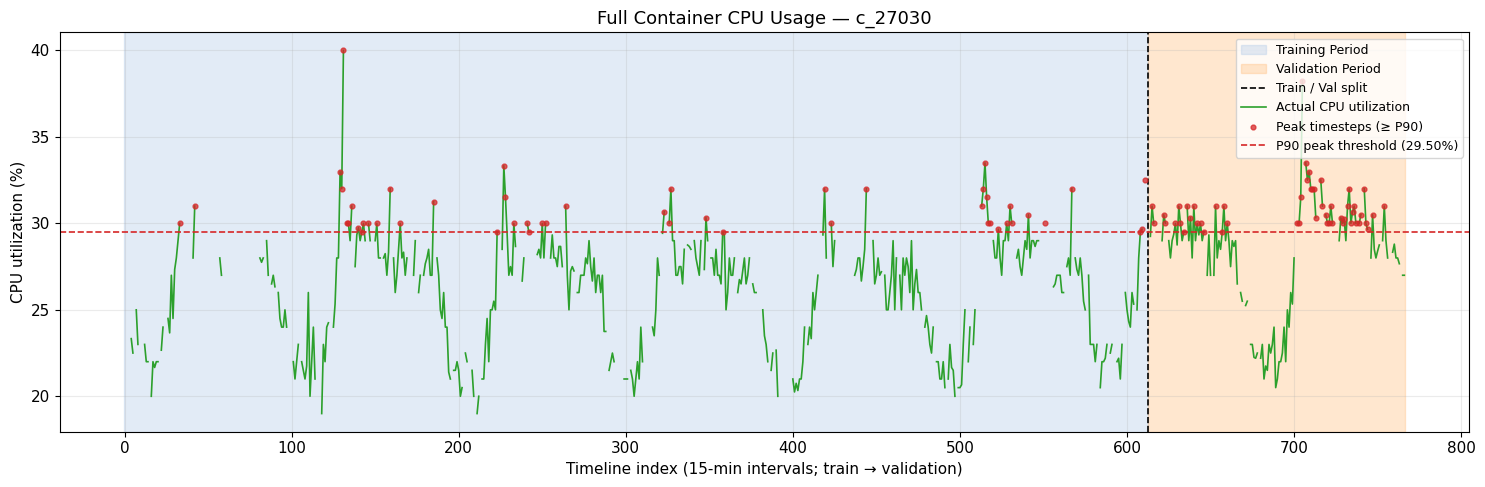

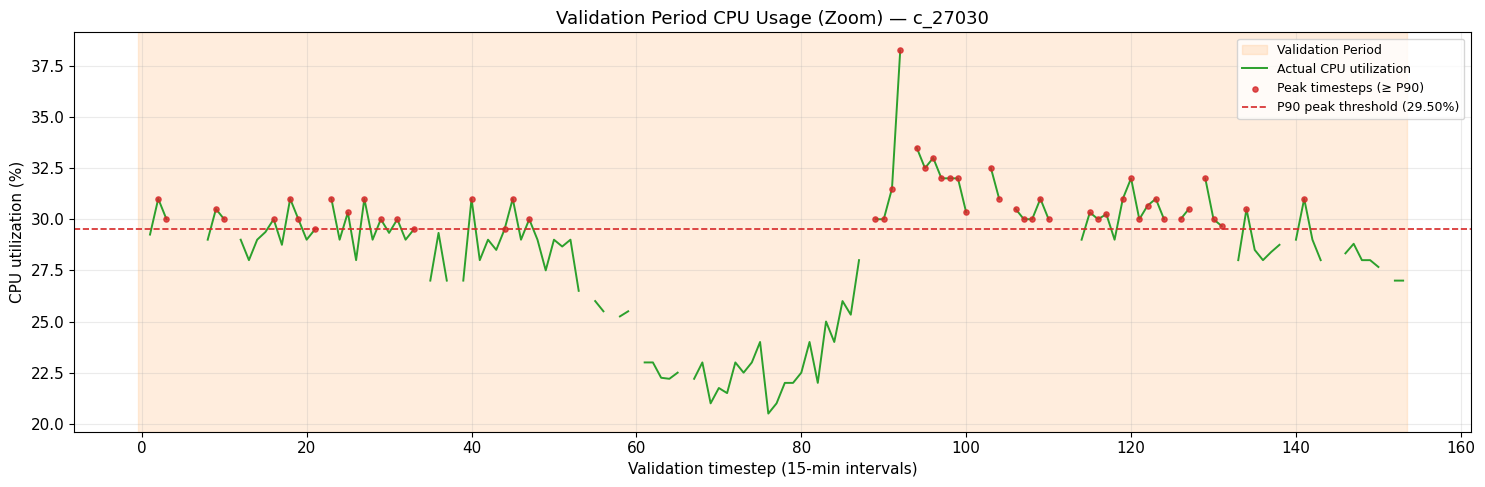


Interpretation:
The selected unseen container exhibits low CPU variability (CV = 0.125) with 101 peak timesteps representing 17.6% of all observations. The forecasting task therefore includes sustained high-utilization periods as well as normal operating regions.
(Descriptive only — no forecasting performed in this section.)


In [170]:
from utils.peak_detection import label_peak_timesteps, load_peak_thresholds

PEAK_THRESHOLDS_PATH = (
    REPO_ROOT / "experiments/peak_aware_2026-07-14_164518/peak/peak_thresholds.pkl"
)

train_usage = train_container.copy()
val_usage = val_container.copy()
train_usage["period"] = "Training Period"
val_usage["period"] = "Validation Period"

full_timeline = pd.concat([train_usage, val_usage], ignore_index=True).sort_values(
    "time_stamp"
)
cpu_real = full_timeline["cpu_util_percent"].astype(float).values
timeline_ts = pd.to_datetime(full_timeline["time_stamp"]).values
n_train = len(train_container)
n_val = len(val_container)
n_total = len(full_timeline)
split_idx = n_train - 0.5  # boundary between last train and first val step

locked_peak_thresholds = load_peak_thresholds(PEAK_THRESHOLDS_PATH)
if UNSEEN_CONTAINER_ID in locked_peak_thresholds:
    usage_peak_threshold = float(locked_peak_thresholds[UNSEEN_CONTAINER_ID])
    threshold_source = str(PEAK_THRESHOLDS_PATH)
else:
    usage_peak_threshold = float(peak_threshold)
    threshold_source = (
        "train-fitted P90 (container absent from locked peak_thresholds.pkl)"
    )

cpu_finite = cpu_real[np.isfinite(cpu_real)]
n_finite = int(len(cpu_finite))
n_excluded = int(n_total - n_finite)
peak_mask_full = np.isfinite(cpu_real) & (cpu_real >= usage_peak_threshold)
peak_count = int(peak_mask_full.sum())
peak_pct = float(peak_count / n_finite * 100.0) if n_finite else float("nan")

mean_cpu = float(np.mean(cpu_finite))
median_cpu = float(np.median(cpu_finite))
min_cpu = float(np.min(cpu_finite))
max_cpu = float(np.max(cpu_finite))
std_cpu = float(np.std(cpu_finite))
cv_cpu = float(std_cpu / mean_cpu) if mean_cpu else float("nan")

COLOR_TRAIN_SHADE = "#AEC7E8"
COLOR_VAL_SHADE = "#FFBB78"
COLOR_CPU_LINE = "#2CA02C"
COLOR_PEAK_MARK = "#D62728"
COLOR_THRESHOLD = "#D62728"

print("=== Unseen container usage statistics ===")
print(f"Container ID              : {UNSEEN_CONTAINER_ID}")
print(f"Total observations        : {n_total}")
print(f"Finite observations       : {n_finite}")
print(f"Excluded non-finite CPU   : {n_excluded}")
print(f"Training observations     : {n_train}")
print(f"Validation observations   : {n_val}")
print(f"Mean CPU (%)              : {mean_cpu:.4f}")
print(f"Median CPU (%)            : {median_cpu:.4f}")
print(f"Minimum CPU (%)           : {min_cpu:.4f}")
print(f"Maximum CPU (%)           : {max_cpu:.4f}")
print(f"Standard deviation (%)    : {std_cpu:.4f}")
print(f"Coefficient of variation  : {cv_cpu:.4f}")
print(f"Peak threshold (P90) (%)  : {usage_peak_threshold:.4f}")
print(f"Peak threshold source     : {threshold_source}")
print(f"Peak count                : {peak_count}")
print(f"Peak percentage (%)       : {peak_pct:.2f}")

step_index_full = np.arange(n_total)

fig, ax = plt.subplots(figsize=(15, 5))
ax.axvspan(-0.5, split_idx, color=COLOR_TRAIN_SHADE, alpha=0.35, label="Training Period")
ax.axvspan(
    split_idx,
    n_total - 0.5,
    color=COLOR_VAL_SHADE,
    alpha=0.35,
    label="Validation Period",
)
ax.axvline(split_idx, color="black", linestyle="--", linewidth=1.2, label="Train / Val split")
ax.plot(
    step_index_full,
    cpu_real,
    color=COLOR_CPU_LINE,
    linewidth=1.2,
    label="Actual CPU utilization",
)
ax.scatter(
    step_index_full[peak_mask_full],
    cpu_real[peak_mask_full],
    s=12,
    color=COLOR_PEAK_MARK,
    alpha=0.75,
    label="Peak timesteps (≥ P90)",
    zorder=3,
)
ax.axhline(
    usage_peak_threshold,
    color=COLOR_THRESHOLD,
    linestyle="--",
    linewidth=1.2,
    label=f"P90 peak threshold ({usage_peak_threshold:.2f}%)",
)
ax.set_title(f"Full Container CPU Usage — {UNSEEN_CONTAINER_ID}")
ax.set_xlabel("Timeline index (15-min intervals; train → validation)")
ax.set_ylabel("CPU utilization (%)")
ax.legend(loc="upper right", fontsize=9)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

val_cpu = val_usage["cpu_util_percent"].astype(float).values
val_step_index = np.arange(n_val)
val_peak_mask = label_peak_timesteps(val_cpu, usage_peak_threshold)

fig, ax = plt.subplots(figsize=(15, 5))
ax.axvspan(-0.5, n_val - 0.5, color=COLOR_VAL_SHADE, alpha=0.25, label="Validation Period")
ax.plot(
    val_step_index,
    val_cpu,
    color=COLOR_CPU_LINE,
    linewidth=1.4,
    label="Actual CPU utilization",
)
ax.scatter(
    val_step_index[val_peak_mask],
    val_cpu[val_peak_mask],
    s=14,
    color=COLOR_PEAK_MARK,
    alpha=0.8,
    label="Peak timesteps (≥ P90)",
    zorder=3,
)
ax.axhline(
    usage_peak_threshold,
    color=COLOR_THRESHOLD,
    linestyle="--",
    linewidth=1.2,
    label=f"P90 peak threshold ({usage_peak_threshold:.2f}%)",
)
ax.set_title(f"Validation Period CPU Usage (Zoom) — {UNSEEN_CONTAINER_ID}")
ax.set_xlabel("Validation timestep (15-min intervals)")
ax.set_ylabel("CPU utilization (%)")
ax.legend(loc="upper right", fontsize=9)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

if cv_cpu >= 0.6:
    variability_label = "high"
elif cv_cpu >= 0.3:
    variability_label = "moderate"
else:
    variability_label = "low"

print()
print("Interpretation:")
print(
    f"The selected unseen container exhibits {variability_label} CPU variability "
    f"(CV = {cv_cpu:.3f}) with {peak_count} peak timesteps representing "
    f"{peak_pct:.1f}% of all observations. The forecasting task therefore includes "
    f"sustained high-utilization periods as well as normal operating regions."
)
print("(Descriptive only — no forecasting performed in this section.)")

## Section 4 – Workload Distribution Analysis

Characterize how CPU utilization distribution differs between the **training** and **validation** periods for the selected unseen container. Descriptive only — no forecasting, Prophet fit, or GRU inference.

Excluded non-finite CPU values — train: 167, validation: 26
=== Distribution statistics (Training vs Validation) ===


,Training,Validation
Observations,446.000000,128.000000
Mean,26.040385,28.214648
Median,27.000000,29.000000
Minimum,19.000000,20.500000
Maximum,40.000000,38.250000
Standard deviation,3.175615,3.191332
Coefficient of variation,0.121950,0.113109
25th percentile,23.083333,27.000000
75th percentile,28.000000,30.000000
90th percentile,29.500000,31.000000


=== Distribution shift analysis ===
Difference in mean CPU                 : +2.1743 %
Difference in median CPU               : +2.0000 %
Difference in standard deviation       : +0.0157 %
Difference in peak percentage          : +29.64 pp
Percentage increase of average CPU     : +8.35 %


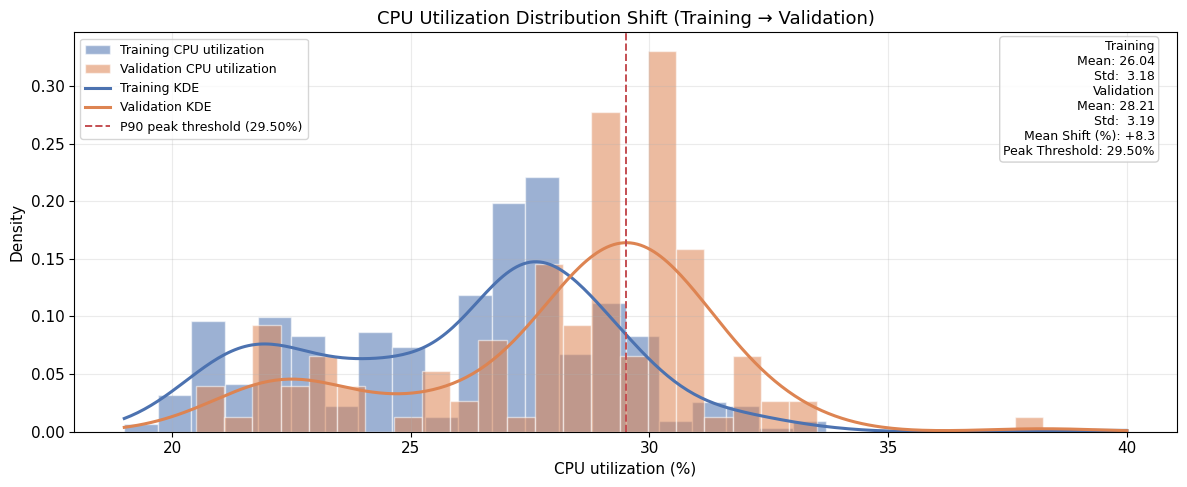

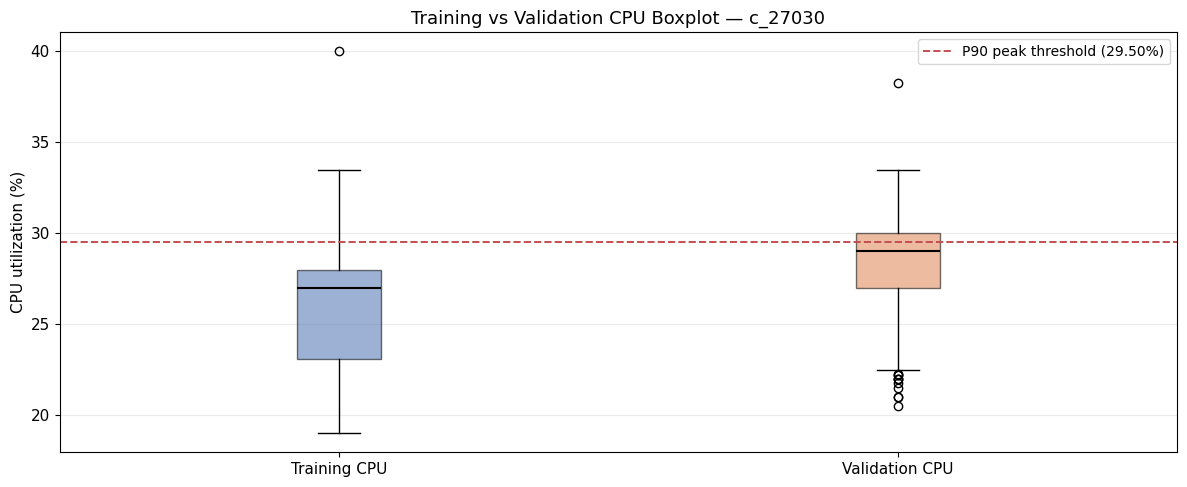


Interpretation:
The validation period exhibits a higher average CPU utilization, and a larger proportion of peak timesteps than the training period, indicating that the forecasting model is evaluated on a more demanding workload than it observed during training.
(Descriptive only — no forecasting performed in this section.)


In [171]:
def _distribution_stats(cpu_arr: np.ndarray, threshold: float) -> dict[str, float]:
    cpu_arr = np.asarray(cpu_arr, dtype=float)
    peak_mask = label_peak_timesteps(cpu_arr, threshold)
    n = int(len(cpu_arr))
    mean = float(np.mean(cpu_arr))
    std = float(np.std(cpu_arr))
    return {
        "Observations": n,
        "Mean": mean,
        "Median": float(np.median(cpu_arr)),
        "Minimum": float(np.min(cpu_arr)),
        "Maximum": float(np.max(cpu_arr)),
        "Standard deviation": std,
        "Coefficient of variation": float(std / mean) if mean else float("nan"),
        "25th percentile": float(np.percentile(cpu_arr, 25)),
        "75th percentile": float(np.percentile(cpu_arr, 75)),
        "90th percentile": float(np.percentile(cpu_arr, 90)),
        "Peak threshold": float(threshold),
        "Peak count": int(peak_mask.sum()),
        "Peak percentage": float(peak_mask.mean() * 100.0) if n else float("nan"),
    }


def _clean_cpu_array(series: pd.Series) -> tuple[np.ndarray, int]:
    """Return finite CPU % values, dropping NaN/inf from interpolated gaps."""
    arr = pd.to_numeric(series, errors="coerce").astype(float).values
    finite_mask = np.isfinite(arr)
    return arr[finite_mask], int((~finite_mask).sum())


train_cpu_dist, train_cpu_excluded = _clean_cpu_array(train_container["cpu_util_percent"])
val_cpu_dist, val_cpu_excluded = _clean_cpu_array(val_container["cpu_util_percent"])
print(
    f"Excluded non-finite CPU values — train: {train_cpu_excluded}, "
    f"validation: {val_cpu_excluded}"
)
if len(train_cpu_dist) == 0 or len(val_cpu_dist) == 0:
    raise ValueError("No finite CPU observations available for distribution analysis.")

train_stats = _distribution_stats(train_cpu_dist, usage_peak_threshold)
val_stats = _distribution_stats(val_cpu_dist, usage_peak_threshold)

dist_compare = pd.DataFrame({"Training": train_stats, "Validation": val_stats})
print("=== Distribution statistics (Training vs Validation) ===")
display(dist_compare)

mean_diff = val_stats["Mean"] - train_stats["Mean"]
median_diff = val_stats["Median"] - train_stats["Median"]
std_diff = val_stats["Standard deviation"] - train_stats["Standard deviation"]
peak_pct_diff = val_stats["Peak percentage"] - train_stats["Peak percentage"]
mean_pct_increase = (
    (mean_diff / train_stats["Mean"] * 100.0) if train_stats["Mean"] else float("nan")
)

print("=== Distribution shift analysis ===")
print(f"Difference in mean CPU                 : {mean_diff:+.4f} %")
print(f"Difference in median CPU               : {median_diff:+.4f} %")
print(f"Difference in standard deviation       : {std_diff:+.4f} %")
print(f"Difference in peak percentage          : {peak_pct_diff:+.2f} pp")
print(f"Percentage increase of average CPU     : {mean_pct_increase:+.2f} %")

HIST_TRAIN_COLOR = "#4C72B0"
HIST_VAL_COLOR = "#DD8452"

from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(
    train_cpu_dist,
    bins=30,
    density=True,
    alpha=0.55,
    color=HIST_TRAIN_COLOR,
    edgecolor="white",
    label="Training CPU utilization",
)
ax.hist(
    val_cpu_dist,
    bins=30,
    density=True,
    alpha=0.55,
    color=HIST_VAL_COLOR,
    edgecolor="white",
    label="Validation CPU utilization",
)

def _safe_gaussian_kde(values: np.ndarray) -> gaussian_kde | None:
    clean = np.asarray(values, dtype=float)
    clean = clean[np.isfinite(clean)]
    if clean.size < 2 or np.std(clean) == 0.0:
        return None
    try:
        return gaussian_kde(clean)
    except (ValueError, np.linalg.LinAlgError):
        return None


kde_x_min = float(min(train_cpu_dist.min(), val_cpu_dist.min()))
kde_x_max = float(
    max(train_cpu_dist.max(), val_cpu_dist.max(), usage_peak_threshold)
)
kde_x = np.linspace(kde_x_min, kde_x_max, 300)
train_kde = _safe_gaussian_kde(train_cpu_dist)
val_kde = _safe_gaussian_kde(val_cpu_dist)
if train_kde is not None:
    ax.plot(
        kde_x,
        train_kde(kde_x),
        color=HIST_TRAIN_COLOR,
        linewidth=2.2,
        label="Training KDE",
    )
else:
    print("Training KDE skipped (insufficient finite variance).")
if val_kde is not None:
    ax.plot(
        kde_x,
        val_kde(kde_x),
        color=HIST_VAL_COLOR,
        linewidth=2.2,
        label="Validation KDE",
    )
else:
    print("Validation KDE skipped (insufficient finite variance).")

ax.axvline(
    usage_peak_threshold,
    color=COLOR_ERROR,
    linestyle="--",
    linewidth=1.4,
    label=f"P90 peak threshold ({usage_peak_threshold:.2f}%)",
)

stats_text = (
    "Training\n"
    f"  Mean: {train_stats['Mean']:.2f}\n"
    f"  Std:  {train_stats['Standard deviation']:.2f}\n"
    "Validation\n"
    f"  Mean: {val_stats['Mean']:.2f}\n"
    f"  Std:  {val_stats['Standard deviation']:.2f}\n"
    f"Mean Shift (%): {mean_pct_increase:+.1f}\n"
    f"Peak Threshold: {usage_peak_threshold:.2f}%"
)
ax.text(
    0.98,
    0.98,
    stats_text,
    transform=ax.transAxes,
    va="top",
    ha="right",
    fontsize=9,
    bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.88, "edgecolor": "#CCCCCC"},
)

ax.set_title("CPU Utilization Distribution Shift (Training → Validation)")
ax.set_xlabel("CPU utilization (%)")
ax.set_ylabel("Density")
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
box = ax.boxplot(
    [train_cpu_dist, val_cpu_dist],
    tick_labels=["Training CPU", "Validation CPU"],
    patch_artist=True,
    showfliers=True,
    medianprops={"color": "black", "linewidth": 1.5},
)
box["boxes"][0].set_facecolor(HIST_TRAIN_COLOR)
box["boxes"][0].set_alpha(0.55)
box["boxes"][1].set_facecolor(HIST_VAL_COLOR)
box["boxes"][1].set_alpha(0.55)
ax.axhline(
    usage_peak_threshold,
    color=COLOR_ERROR,
    linestyle="--",
    linewidth=1.4,
    label=f"P90 peak threshold ({usage_peak_threshold:.2f}%)",
)
ax.set_title(
    f"Training vs Validation CPU Boxplot — {UNSEEN_CONTAINER_ID}"
)
ax.set_ylabel("CPU utilization (%)")
ax.legend(loc="best")
ax.grid(alpha=0.25, axis="y")
plt.tight_layout()
plt.show()

higher_mean = mean_diff > 0.05
lower_mean = mean_diff < -0.05
higher_std = std_diff > 0.05
higher_peak_share = peak_pct_diff > 1.0

print()
print("Interpretation:")
if higher_mean or higher_std or higher_peak_share:
    parts = []
    if higher_mean:
        parts.append("a higher average CPU utilization")
    if higher_std:
        parts.append("greater variability")
    if higher_peak_share:
        parts.append("a larger proportion of peak timesteps")
    detail = ", ".join(parts[:-1]) + (
        f", and {parts[-1]}" if len(parts) > 1 else parts[0]
    )
    print(
        f"The validation period exhibits {detail} than the training period, "
        "indicating that the forecasting model is evaluated on a more demanding "
        "workload than it observed during training."
    )
elif lower_mean and not higher_std and not higher_peak_share:
    print(
        "The validation period exhibits lower average CPU utilization than the "
        "training period, with broadly similar variability and peak burden."
    )
else:
    print(
        "The training and validation CPU distributions are broadly similar, with "
        "only modest shifts in mean utilization, variability, and peak share."
    )
print("(Descriptive only — no forecasting performed in this section.)")


## Section 5 — Fit Prophet

Fit a **new** Prophet model on the unseen container's training period only (80% chronological split). Validation data is not used during fitting.

In [172]:
prophet_train = pd.DataFrame({
    "ds": train_container["time_stamp"],
    "y": train_container["cpu_scaled"],
})

prophet_model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=False,
)
prophet_model.fit(prophet_train)

future_df = pd.DataFrame({
    "ds": val_container["time_stamp"].values[:DAY1_HORIZON],
})
prophet_day1_forecast = prophet_model.predict(future_df)
prophet_day1_scaled = prophet_day1_forecast["yhat"].values

scaler = scalers[UNSEEN_CONTAINER_ID]
prophet_day1_real_preview = scaler.inverse_transform(
    prophet_day1_scaled.reshape(-1, 1)
).ravel()
actual_day1_real_preview = scaler.inverse_transform(
    val_container["cpu_scaled"].values[:DAY1_HORIZON].reshape(-1, 1)
).ravel()

print(f"Prophet trained on {len(prophet_train)} train timesteps")
print(f"Day-1 Prophet forecast length : {len(prophet_day1_scaled)} steps")
print(
    f"Preview Prophet Day-1 MAE : "
    f"{np.mean(np.abs(actual_day1_real_preview - prophet_day1_real_preview)):.4f} %"
)

23:50:25 - cmdstanpy - INFO - Chain [1] start processing
23:50:25 - cmdstanpy - INFO - Chain [1] done processing


Prophet trained on 613 train timesteps
Day-1 Prophet forecast length : 96 steps
Preview Prophet Day-1 MAE : 1.0902 %


## Section 6 — Run frozen Hybrid inference

Reuse the locked `run_hybrid_inference()` pipeline: container-specific Prophet fit, frozen global residual normalization, and frozen Hybrid GRU weights.

In [173]:
result = run_hybrid_inference(
    container_id=UNSEEN_CONTAINER_ID,
    global_train=global_train,
    global_val=global_val,
    hybrid_gru_model=hybrid_gru_model,
    scalers=scalers,
    res_mean=res_mean,
    res_std=res_std,
    input_window=INPUT_WINDOW,
    day1_horizon=DAY1_HORIZON,
)

actual = np.ravel(result.actual_day1_real)
hybrid_pred = np.ravel(result.day1_final_real)
prophet_pred = np.ravel(result.prophet_day1_real)
residual_pred = np.ravel(result.day1_residual)

train_forecast = result.prophet_model.predict(result.prophet_train[["ds"]])
train_residual = (
    result.train_container["cpu_scaled"].values - train_forecast["yhat"].values
)
actual_residual = actual - prophet_pred

timestamps = val_container["time_stamp"].values[:DAY1_HORIZON]
step_index = np.arange(DAY1_HORIZON)

print(f"Inference complete for {result.container_id}")
print(f"Train steps used : {result.n_train_steps}")
print(f"Val steps used   : {result.n_val_steps}")
print(f"GRU input window : {result.input_window}")
print(f"Day-1 horizon    : {result.day1_horizon}")

23:50:26 - cmdstanpy - INFO - Chain [1] start processing
23:50:26 - cmdstanpy - INFO - Chain [1] done processing


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Inference complete for c_27030
Train steps used : 613
Val steps used   : 154
GRU input window : 96
Day-1 horizon    : 96


## Section 7 — Evaluation metrics

Day-1 metrics use the same functions as the locked Hybrid evaluation protocol.

In [174]:
day1_mae, day1_rmse = compute_day1_metrics(actual, hybrid_pred)
day1_mape = compute_day1_mape(actual, hybrid_pred, epsilon=MAPE_EPSILON)

peak_metrics = compute_peak_subset_metrics(result, peak_threshold)
abs_error = np.abs(actual - hybrid_pred)

metrics = pd.DataFrame(
    [
        {"metric": "MAE", "value": day1_mae},
        {"metric": "RMSE", "value": day1_rmse},
        {"metric": "MAPE (%)", "value": day1_mape},
        {"metric": "Peak MAE", "value": peak_metrics["peak_mae"]},
        {"metric": "Peak RMSE", "value": peak_metrics["peak_rmse"]},
        {"metric": "Non-Peak MAE", "value": peak_metrics["non_peak_mae"]},
        {"metric": "Non-Peak RMSE", "value": peak_metrics["non_peak_rmse"]},
        {"metric": "Max absolute error", "value": float(abs_error.max())},
        {"metric": "Peak steps", "value": peak_metrics["peak_steps"]},
        {"metric": "Non-peak steps", "value": peak_metrics["non_peak_steps"]},
    ]
)

display(metrics)

,metric,value
0,MAE,1.089383
1,RMSE,1.497440
2,MAPE (%),3.946289
3,Peak MAE,1.433712
4,Peak RMSE,2.153116
5,Non-Peak MAE,0.947601
6,Non-Peak RMSE,1.121041
7,Max absolute error,8.017905
8,Peak steps,28.000000
9,Non-peak steps,68.000000


## Section 8 — Visualization

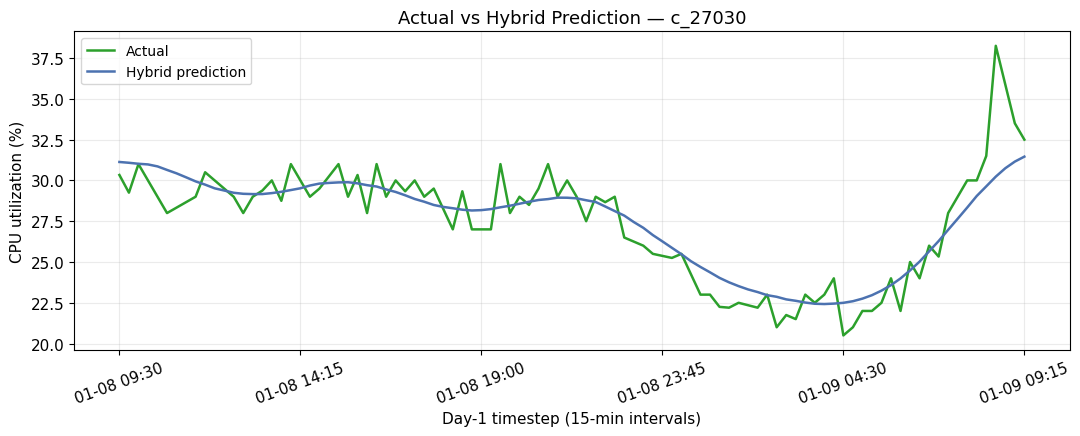

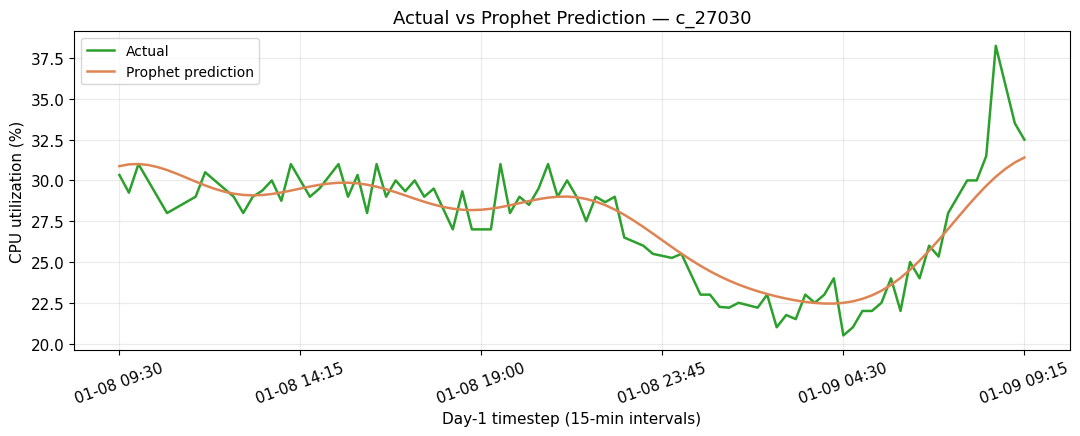

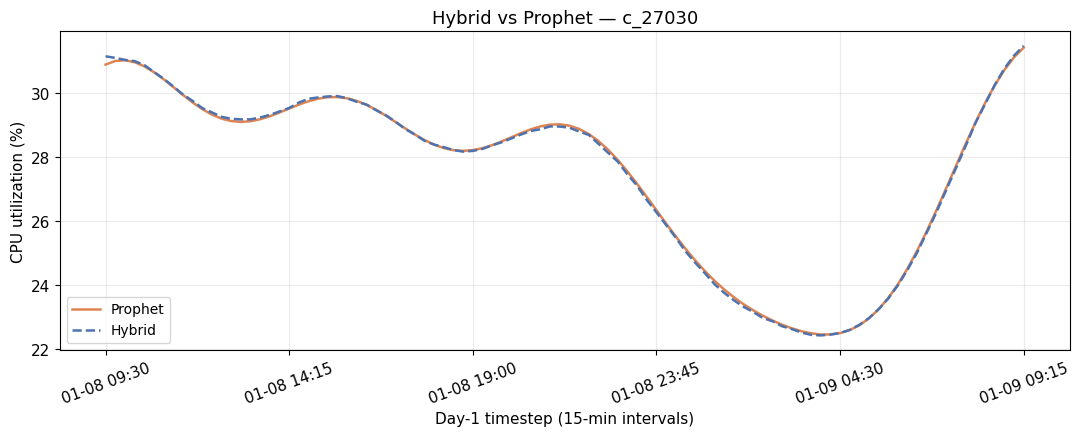

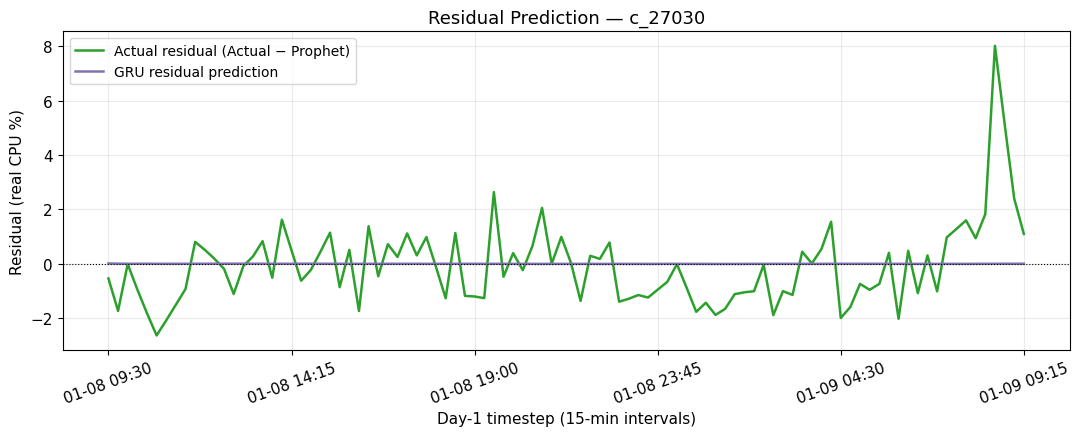

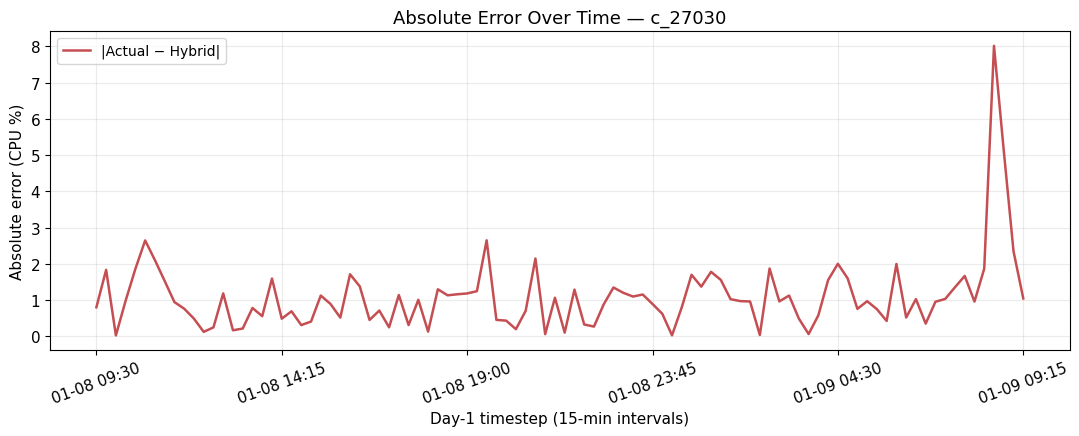

In [175]:
def _format_time_axis(ax, timestamps: np.ndarray) -> None:
    tick_positions = np.linspace(0, len(timestamps) - 1, num=6, dtype=int)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(
        pd.to_datetime(timestamps[tick_positions]).strftime("%m-%d %H:%M"),
        rotation=20,
    )


fig, ax = plt.subplots()
ax.plot(step_index, actual, label="Actual", color=COLOR_ACTUAL, linewidth=1.8)
ax.plot(step_index, hybrid_pred, label="Hybrid prediction", color=COLOR_HYBRID, linewidth=1.8)
ax.set_title(f"Actual vs Hybrid Prediction — {UNSEEN_CONTAINER_ID}")
ax.set_xlabel("Day-1 timestep (15-min intervals)")
ax.set_ylabel("CPU utilization (%)")
ax.legend(loc="best")
ax.grid(alpha=0.25)
_format_time_axis(ax, timestamps)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots()
ax.plot(step_index, actual, label="Actual", color=COLOR_ACTUAL, linewidth=1.8)
ax.plot(step_index, prophet_pred, label="Prophet prediction", color=COLOR_PROPHET, linewidth=1.8)
ax.set_title(f"Actual vs Prophet Prediction — {UNSEEN_CONTAINER_ID}")
ax.set_xlabel("Day-1 timestep (15-min intervals)")
ax.set_ylabel("CPU utilization (%)")
ax.legend(loc="best")
ax.grid(alpha=0.25)
_format_time_axis(ax, timestamps)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots()
ax.plot(step_index, prophet_pred, label="Prophet", color=COLOR_PROPHET, linewidth=1.8)
ax.plot(step_index, hybrid_pred, label="Hybrid", color=COLOR_HYBRID, linewidth=1.8, linestyle="--")
ax.set_title(f"Hybrid vs Prophet — {UNSEEN_CONTAINER_ID}")
ax.set_xlabel("Day-1 timestep (15-min intervals)")
ax.set_ylabel("CPU utilization (%)")
ax.legend(loc="best")
ax.grid(alpha=0.25)
_format_time_axis(ax, timestamps)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots()
ax.plot(step_index, actual_residual, label="Actual residual (Actual − Prophet)", color=COLOR_ACTUAL, linewidth=1.8)
ax.plot(step_index, residual_pred, label="GRU residual prediction", color=COLOR_RESIDUAL, linewidth=1.8)
ax.axhline(0.0, color="black", linewidth=0.8, linestyle=":")
ax.set_title(f"Residual Prediction — {UNSEEN_CONTAINER_ID}")
ax.set_xlabel("Day-1 timestep (15-min intervals)")
ax.set_ylabel("Residual (real CPU %)")
ax.legend(loc="best")
ax.grid(alpha=0.25)
_format_time_axis(ax, timestamps)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots()
ax.plot(step_index, abs_error, label="|Actual − Hybrid|", color=COLOR_ERROR, linewidth=1.8)
ax.set_title(f"Absolute Error Over Time — {UNSEEN_CONTAINER_ID}")
ax.set_xlabel("Day-1 timestep (15-min intervals)")
ax.set_ylabel("Absolute error (CPU %)")
ax.legend(loc="best")
ax.grid(alpha=0.25)
_format_time_axis(ax, timestamps)
plt.tight_layout()
plt.show()

## Section 9 — Discussion

This notebook demonstrates inference on **one container that was never used during Hybrid GRU training**. The frozen GRU was trained on sequences from the 100 containers in `selected_containers.npy`; the container selected here comes from the remaining preprocessed cohort.

It is intended as a **qualitative demonstration of cross-container generalization**: the model must forecast residuals for a workload whose history was not part of GRU training, while Prophet is refit on that container's own training period.

**Important scope boundary:**

- This is **not** part of the locked experimental comparison.
- It **must not replace** the official Day-1 evaluation over the 99-container selected cohort.
- Metrics shown here describe a single unseen container only and are not comparable to cohort-level aggregate results without further study design.

Official locked results remain in:

- `experiments/baseline_reference_2026-07-14/`
- `experiments/final_model_comparison_2026-07-23_070654/`